# Bayesian DenseNet-121 (MC Dropout) untuk Grading Diabetic Retinopathy

Notebook ini mengimplementasikan Bayesian CNN dengan **Monte Carlo Dropout** untuk klasifikasi 5 grade diabetic retinopathy (No-DR, Mild, Moderate, Severe, Proliferative-DR), menggunakan backbone **DenseNet-121**.

Referensi teknik: Akram et al. (2025), *"Uncertainty-aware diabetic retinopathy detection using deep learning enhanced by Bayesian approaches"*, Scientific Reports 15:1342, dengan modifikasi preprocessing (Ben Graham radius normalization + circular crop + CLAHE) agar lebih robust saat menggabungkan dataset APTOS 2019 + Lokal yang berasal dari sumber kamera berbeda-beda.

**Keputusan desain notebook ini:**
- Loss: categorical cross-entropy (softmax 5 kelas) — bukan ordinal CORAL.
- Dataset: APTOS 2019 + Lokal digabung dan diseimbangkan per kelas.
- Preprocessing: Ben Graham radius normalization + circular crop + CLAHE + local-average subtraction.
- Uncertainty: MC Dropout dengan isolasi BatchNorm/Dropout yang benar saat inference (BatchNorm tetap eval mode, hanya layer Dropout yang diaktifkan kembali).


In [ ]:
# @title 1a. Install kagglehub & mount Google Drive
!pip install -q kagglehub

from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# @title 1b. Install dependencies
!pip install -q torch torchvision torchmetrics opencv-python-headless scikit-learn kaggle albumentations kornia
print("Dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 63.7 MB/s eta 0:00:00
Dependencies installed.


In [ ]:
# @title 2. Imports
import os, json, random, math, shutil, zipfile, glob
from pathlib import Path
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import DenseNet121_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
cv2.setNumThreads(0)

In [ ]:
# @title 3. Config
@dataclass
class Config:
    IMG_SIZE: int = 224
    NUM_CLASSES: int = 5
    BATCH_SIZE: int = 64
    EPOCHS: int = 40
    LR: float = 5e-5
    WEIGHT_DECAY: float = 5e-5
    DROPOUT_P: float = 0.3
    MC_T: int = 50
    SEED: int = 42
    TARGET_PER_CLASS: int = 1500
    DATA_ROOT: str = "/content/data"
    PROCESSED_DIR: str = "/content/data/processed_224"
    CKPT_PATH: str = "/content/bayesian_densenet121_mcdropout.pt"


cfg = Config()


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(cfg.SEED)
os.makedirs(cfg.DATA_ROOT, exist_ok=True)
os.makedirs(cfg.PROCESSED_DIR, exist_ok=True)
print(cfg)

Config(IMG_SIZE=224, NUM_CLASSES=5, BATCH_SIZE=64, EPOCHS=40, LR=5e-05, WEIGHT_DECAY=5e-05, DROPOUT_P=0.3, MC_T=50, SEED=42, TARGET_PER_CLASS=1500, DATA_ROOT='/content/data', PROCESSED_DIR='/content/data/processed_224', CKPT_PATH='/content/bayesian_densenet121_mcdropout.pt')


## 4. Ambil dataset: APTOS 2019 (kagglehub) + dataset lokal (Google Drive)

- APTOS 2019: diunduh otomatis via `kagglehub` (sudah di-resize 224x224 oleh pembuat dataset), tidak perlu setup Kaggle API key manual.
- Dataset lokal: dibaca langsung dari Google Drive kamu, struktur folder per kelas (`No_DR/`, `Mild/`, `Moderate/`, `Severe/`, `Proliferate_DR/`).

In [ ]:
# @title 4a. Download APTOS 2019 (kagglehub, sudah 224x224)
import kagglehub

aptos_path = kagglehub.dataset_download(
    "sovitrath/diabetic-retinopathy-224x224-2019-data"
)
print("Path to dataset files:", aptos_path)

# struktur dataset ini: <aptos_path>/train.csv + <aptos_path>/colored_images/<kelas>/<id_code>.png
!ls "{aptos_path}"

100%|██████████| 238M/238M [00:14<00:00, 17.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sovitrath/diabetic-retinopathy-224x224-2019-data/versions/4
colored_images	train.csv


In [ ]:
# @title 4b. Copy dataset lokal dari Google Drive ke disk lokal Colab
from tqdm.auto import tqdm

LOCAL_DR_DIR_DRIVE = "/content/drive/MyDrive/BayesianCNN/Dataset/Lokal"
LOCAL_DR_DIR = "/content/data/local_raw"  # <- dari sini seterusnya, ini yang dipakai (bukan path Drive)


def copy_drive_to_local(src_dir, dst_dir):
    os.makedirs(dst_dir, exist_ok=True)
    all_files = [
        f
        for f in glob.glob(os.path.join(src_dir, "**", "*"), recursive=True)
        if os.path.isfile(f)
    ]
    copied, skipped = 0, 0
    for src_fp in tqdm(all_files, desc="Copy Drive -> lokal Colab"):
        rel_path = os.path.relpath(src_fp, src_dir)
        dst_fp = os.path.join(dst_dir, rel_path)
        os.makedirs(os.path.dirname(dst_fp), exist_ok=True)
        if os.path.exists(dst_fp) and os.path.getsize(dst_fp) == os.path.getsize(
            src_fp
        ):
            skipped += 1
            continue
        shutil.copy2(src_fp, dst_fp)
        copied += 1
    print(
        f"Selesai copy: {copied} file baru, {skipped} file sudah ada (di-skip, idempotent kalau re-run)."
    )


copy_drive_to_local(LOCAL_DR_DIR_DRIVE, LOCAL_DR_DIR)

print("Isi folder lokal:")
for cls in ["No_DR", "Mild", "Moderate", "Severe", "Proliferate_DR"]:
    n = len(glob.glob(os.path.join(LOCAL_DR_DIR, cls, "*")))
    print(f"  {cls}: {n} file")

Copy Drive -> lokal Colab:   0%|          | 0/352 [00:00<?, ?it/s]

Selesai copy: 352 file baru, 0 file sudah ada (di-skip, idempotent kalau re-run).
Isi folder lokal:
  No_DR: 41 file
  Mild: 29 file
  Moderate: 59 file
  Severe: 67 file
  Proliferate_DR: 156 file


In [ ]:
# @title 5a. Build unified dataframe (APTOS + lokal, sama-sama struktur class_folders)
CLASS_ALIASES = {
    0: ["No_DR", "0"],
    1: ["Mild", "1"],
    2: ["Moderate", "2"],
    3: ["Severe", "3"],
    4: ["Proliferate_DR", "4"],
}


def load_class_folder_df(root_dir, source_name):
    rows = []
    for label, aliases in CLASS_ALIASES.items():
        folder_path = next(
            (
                os.path.join(root_dir, a)
                for a in aliases
                if os.path.isdir(os.path.join(root_dir, a))
            ),
            None,
        )
        if folder_path is None:
            continue
        for fp in glob.glob(os.path.join(folder_path, "*")):
            if fp.lower().endswith((".png", ".jpg", ".jpeg")):
                rows.append({"filepath": fp, "label": label, "source": source_name})
    return pd.DataFrame(rows)


aptos_df = load_class_folder_df(os.path.join(aptos_path, "colored_images"), "aptos")
print("Aptos")
print(aptos_df["label"].value_counts().sort_index())
print("\n")

local_df = load_class_folder_df(LOCAL_DR_DIR, "local")
print("Local")
print(local_df["label"].value_counts().sort_index())
print("\n")

full_df = pd.concat([aptos_df, local_df], ignore_index=True)
full_df = full_df[full_df["filepath"].apply(os.path.exists)].reset_index(drop=True)
print(
    "APTOS:",
    len(aptos_df),
    "| Local:",
    len(local_df),
    "| combined (valid files):",
    len(full_df),
)
print(full_df["label"].value_counts().sort_index())

Aptos
label
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


Local
label
0     41
1     29
2     59
3     67
4    156
Name: count, dtype: int64


APTOS: 3662 | Local: 352 | combined (valid files): 4014
label
0    1846
1     399
2    1058
3     260
4     451
Name: count, dtype: int64


## 6. Preprocessing pipeline

Empat tahap, dijalankan berurutan per citra:

1. **Deteksi & crop retina** — threshold grayscale untuk menemukan bounding circle retina (fallback: pakai citra utuh jika deteksi gagal, mengikuti strategi paper agar tidak kehilangan data).
2. **Radius normalization (Ben Graham)** — resize sehingga radius retina konsisten (default 300px) di semua citra, penting karena APTOS dan DDR punya resolusi & FOV kamera berbeda.
3. **Circular mask** — nolkan piksel di luar lingkaran retina agar CNN tidak belajar artefak sudut.
4. **CLAHE + local-average subtraction (BEN-style)** — enhance kontras lokal dan lesi (microaneurysm, hemorrhage, exudate) sambil menormalkan brightness antar sumber data.

Hasil akhir: citra RGB 224x224.

In [ ]:
# @title 6a. Preprocessing functions
def _detect_retina_circle(gray, thresh=7):
    mask = gray > thresh
    if mask.sum() == 0:
        return None
    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0)
    return x0, y0, x1, y1


def _scale_radius(img, target_radius=300):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    row = gray[gray.shape[0] // 2, :]
    row_thresh = row > row.mean() / 10
    nz = np.nonzero(row_thresh)[0]
    if len(nz) < 2:
        return img
    current_radius = (nz[-1] - nz[0]) / 2
    if current_radius <= 1:
        return img
    scale = target_radius / current_radius
    scale = float(np.clip(scale, 0.1, 10.0))
    return cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)


def _circular_mask(img, radius_fraction=0.98):
    h, w = img.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    center = (w // 2, h // 2)
    radius = int(min(h, w) / 2 * radius_fraction)
    cv2.circle(mask, center, radius, 255, -1)
    out = cv2.bitwise_and(img, img, mask=mask)
    return out


def _clahe_rgb(img, clip_limit=2.5, tile=(8, 8)):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile)
    l2 = clahe.apply(l)
    lab2 = cv2.merge((l2, a, b))
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)


def _local_average_subtract(img, sigma_fraction=30):
    sigma = max(img.shape[0], img.shape[1]) / sigma_fraction
    blurred = cv2.GaussianBlur(img, (0, 0), sigma)
    out = cv2.addWeighted(img, 4, blurred, -4, 128)
    return out


def preprocess_image(img_rgb, img_size=224, target_radius=300):
    """Full pipeline: crop -> radius normalize -> circular mask -> CLAHE -> local-avg subtract -> resize.
    Falls back to a plain resize if retina detection fails, to avoid discarding data."""
    try:
        gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
        box = _detect_retina_circle(gray, thresh=7)
        if box is not None:
            x0, y0, x1, y1 = box
            if (x1 - x0) > 10 and (y1 - y0) > 10:
                img_rgb = img_rgb[y0:y1, x0:x1]
        img_rgb = _scale_radius(img_rgb, target_radius=target_radius)
        img_rgb = _circular_mask(img_rgb, radius_fraction=0.98)
        img_rgb = _clahe_rgb(img_rgb)
        img_rgb = _local_average_subtract(img_rgb, sigma_fraction=30)
    except Exception as e:
        pass  # fallback: use image as-is (paper's "keep original to avoid data loss" strategy)

    # square-pad before resize to avoid distortion
    h, w = img_rgb.shape[:2]
    side = max(h, w)
    padded = np.zeros((side, side, 3), dtype=img_rgb.dtype)
    y_off, x_off = (side - h) // 2, (side - w) // 2
    padded[y_off : y_off + h, x_off : x_off + w] = img_rgb
    out = cv2.resize(padded, (img_size, img_size), interpolation=cv2.INTER_AREA)
    return out

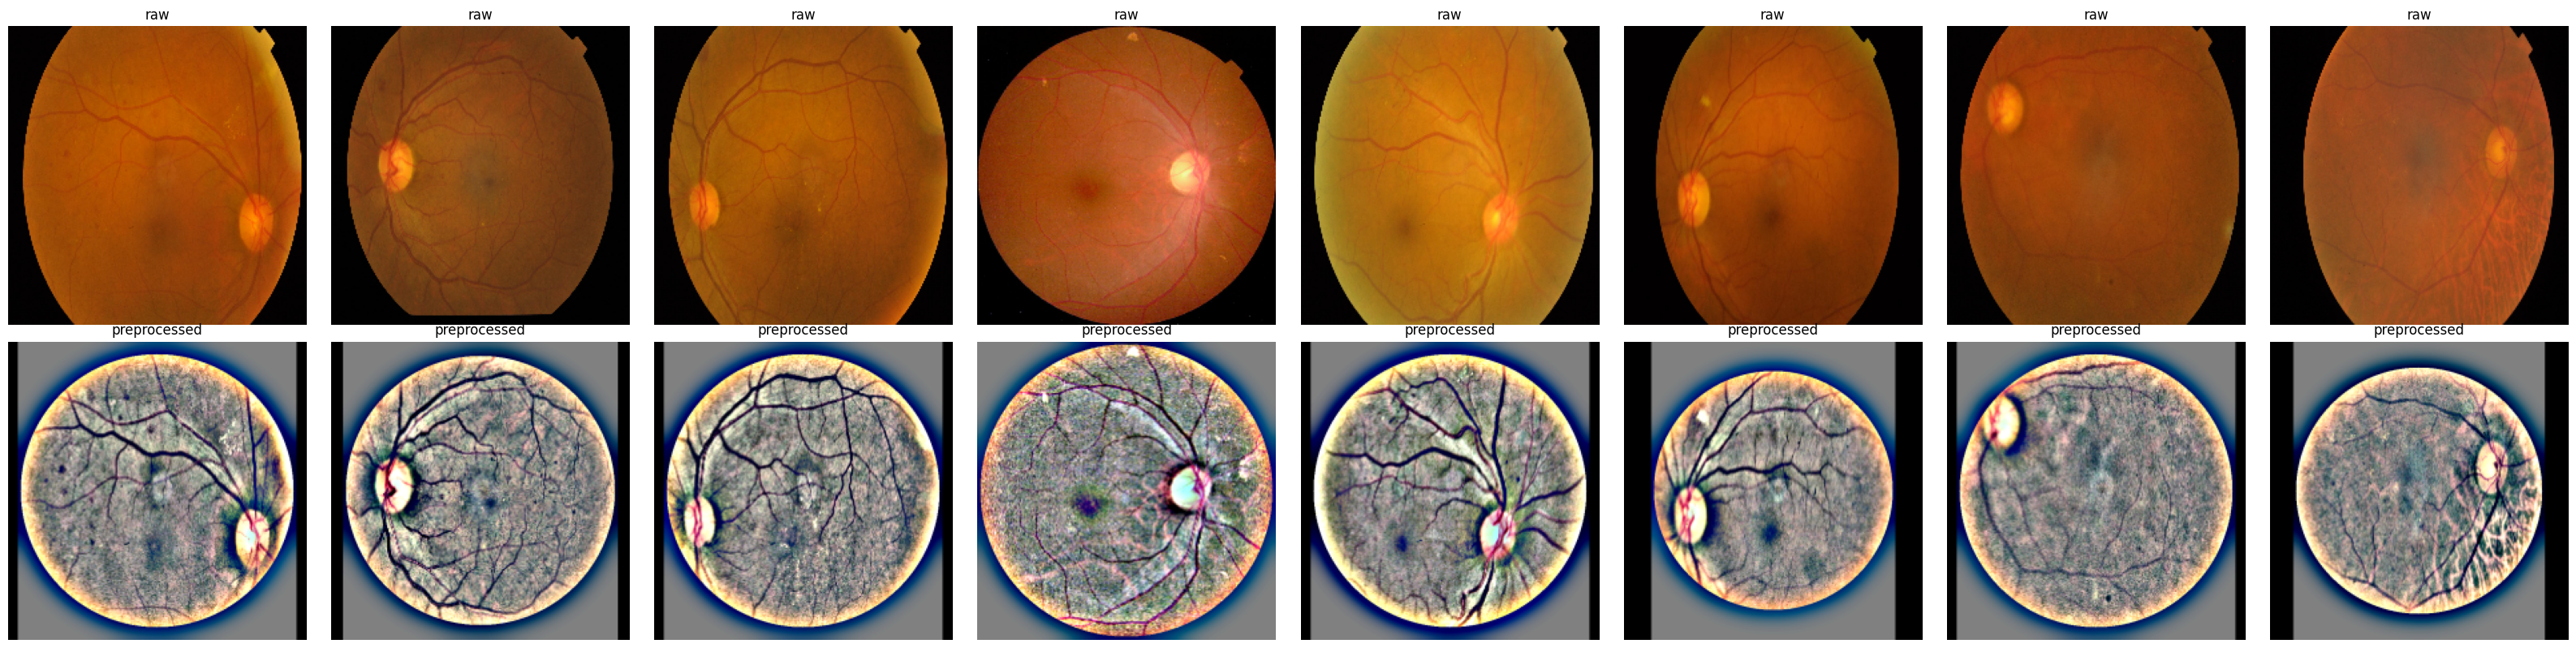

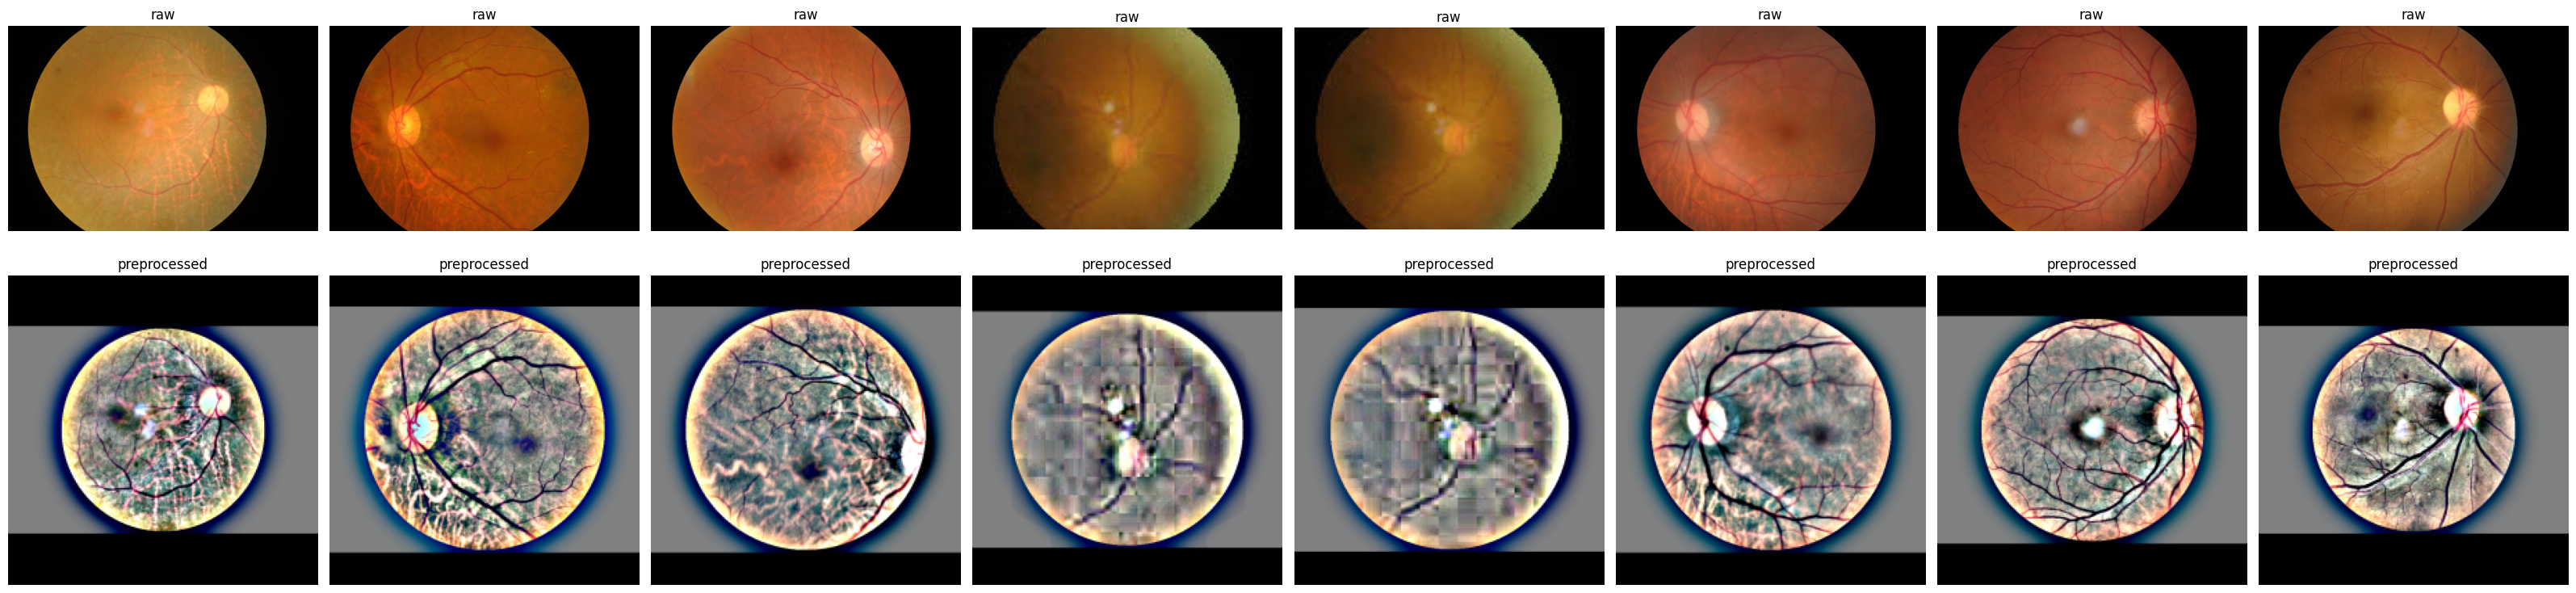

In [ ]:
# @title 6b. Sanity check preprocessing on sample images
def _load_rgb(path):
    img = cv2.imread(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


aptos_sample_paths = glob.glob(f"{aptos_path}/**/*.png", recursive=True)[:8]
if len(aptos_sample_paths) > 0:
    fig, axes = plt.subplots(
        2, len(aptos_sample_paths), figsize=(4 * len(aptos_sample_paths), 8)
    )
    for i, p in enumerate(aptos_sample_paths):
        raw = _load_rgb(p)
        proc = preprocess_image(raw, img_size=cfg.IMG_SIZE)
        axes[0, i].imshow(raw)
        axes[0, i].set_title("raw")
        axes[0, i].axis("off")
        axes[1, i].imshow(proc)
        axes[1, i].set_title("preprocessed")
        axes[1, i].axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No sample aptos images found yet - run the download cells first.")

print("\n")

local_sample_paths = glob.glob(f"{LOCAL_DR_DIR}/**/*.jpg", recursive=True)[:8]
if len(local_sample_paths) > 0:
    fig, axes = plt.subplots(
        2, len(local_sample_paths), figsize=(4 * len(local_sample_paths), 8)
    )
    for i, p in enumerate(local_sample_paths):
        raw = _load_rgb(p)
        proc = preprocess_image(raw, img_size=cfg.IMG_SIZE)
        axes[0, i].imshow(raw)
        axes[0, i].set_title("raw")
        axes[0, i].axis("off")
        axes[1, i].imshow(proc)
        axes[1, i].set_title("preprocessed")
        axes[1, i].axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No sample local images found yet - run the download cells first.")

## 7. Gabungkan APTOS 2019 + dataset lokal, seimbangkan kelas

APTOS 2019 (via kagglehub) dan dataset lokal di Google Drive digabung ke skema label yang sama (0-4), lalu diseimbangkan: kelas minoritas di-oversample (dengan replacement), kelas mayoritas di-undersample, ditarget `TARGET_PER_CLASS` sampel per kelas.

In [ ]:
# @title 6b. Precompute preprocessed cache (di atas SELURUH data mentah, sebelum split & balancing)
from tqdm.auto import tqdm


def cache_dataframe_locally(df, processed_dir):
    os.makedirs(processed_dir, exist_ok=True)
    cached_rows, failed = [], []
    for i, row in tqdm(df.iterrows(), total=len(df), desc="Caching"):
        label = int(row["label"])
        class_dir = os.path.join(processed_dir, str(label))
        os.makedirs(class_dir, exist_ok=True)
        dst_path = os.path.join(class_dir, f"{row['source']}_{i}.jpg")

        if os.path.exists(dst_path):
            cached_rows.append(
                {"filepath": dst_path, "label": label, "source": row["source"]}
            )
            continue

        img = cv2.imread(row["filepath"])
        if img is None:
            failed.append(row["filepath"])
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        proc = preprocess_image(img, img_size=cfg.IMG_SIZE)
        proc_bgr = cv2.cvtColor(proc, cv2.COLOR_RGB2BGR)
        cv2.imwrite(dst_path, proc_bgr, [cv2.IMWRITE_JPEG_QUALITY, 95])
        cached_rows.append(
            {"filepath": dst_path, "label": label, "source": row["source"]}
        )

    print(f"Cached: {len(cached_rows)} | Gagal dibaca (di-skip): {len(failed)}")
    if failed:
        print("Contoh file gagal:", failed[:5])
    return pd.DataFrame(cached_rows)


full_df = cache_dataframe_locally(full_df, cfg.PROCESSED_DIR)
print(full_df["label"].value_counts().sort_index())

Caching:   0%|          | 0/4014 [00:00<?, ?it/s]

Cached: 4013 | Gagal dibaca (di-skip): 1
Contoh file gagal: ['/content/data/local_raw/Proliferate_DR/vk014297.jpg']
label
0    1846
1     399
2    1058
3     260
4     450
Name: count, dtype: int64


In [ ]:
# @title 6c. Stratified train/val/test split - tiap file unik hanya masuk SATU split
train_df, temp_df = train_test_split(
    full_df, test_size=0.2, stratify=full_df["label"], random_state=cfg.SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=cfg.SEED
)

print("Distribusi asli (sebelum balancing train):")
print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))
print(train_df["label"].value_counts().sort_index())

Distribusi asli (sebelum balancing train):
Train: 3210 | Val: 401 | Test: 402
label
0    1477
1     319
2     846
3     208
4     360
Name: count, dtype: int64


Train setelah balancing:
label
0    1500
1    1500
2    1500
3    1500
4    1500
Name: count, dtype: int64


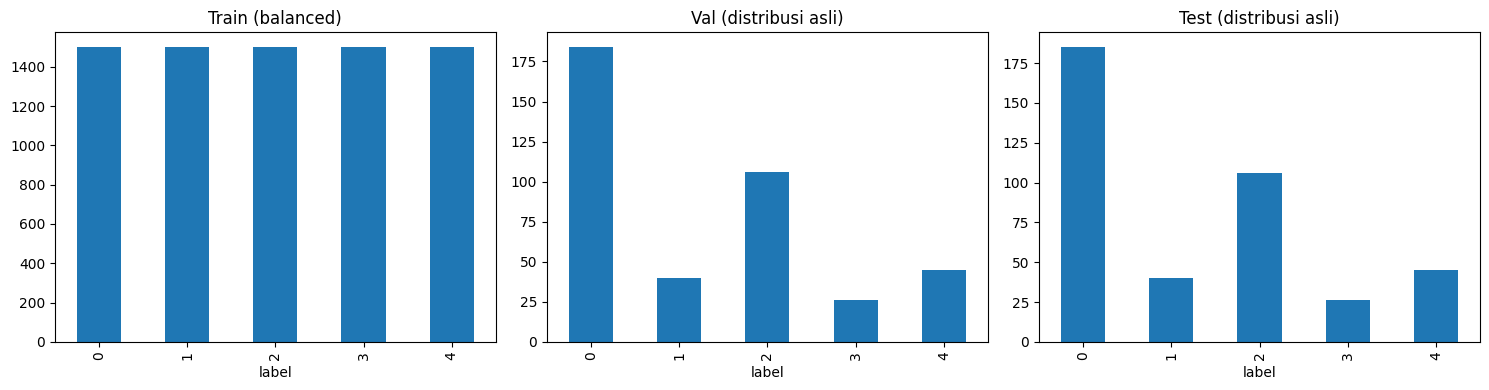

In [ ]:
# @title 6d. Balance HANYA train set (val/test tetap distribusi asli - representasi dunia nyata)
def balance_classes(df, target_per_class, seed=42):
    balanced = []
    for cls in sorted(df["label"].unique()):
        cls_df = df[df["label"] == cls]
        if len(cls_df) >= target_per_class:
            sampled = cls_df.sample(
                n=target_per_class, random_state=seed, replace=False
            )
        else:
            sampled = cls_df.sample(n=target_per_class, random_state=seed, replace=True)
        balanced.append(sampled)
    return pd.concat(balanced, ignore_index=True)


train_df = balance_classes(train_df, cfg.TARGET_PER_CLASS, seed=cfg.SEED)

print("Train setelah balancing:")
print(train_df["label"].value_counts().sort_index())

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
train_df["label"].value_counts().sort_index().plot(
    kind="bar", ax=ax[0], title="Train (balanced)"
)
val_df["label"].value_counts().sort_index().plot(
    kind="bar", ax=ax[1], title="Val (distribusi asli)"
)
test_df["label"].value_counts().sort_index().plot(
    kind="bar", ax=ax[2], title="Test (distribusi asli)"
)
plt.tight_layout()
plt.show()

train_df.to_csv(f"{cfg.DATA_ROOT}/train_split.csv", index=False)
val_df.to_csv(f"{cfg.DATA_ROOT}/val_split.csv", index=False)
test_df.to_csv(f"{cfg.DATA_ROOT}/test_split.csv", index=False)

In [ ]:
print(train_df["filepath"].iloc[7400])

/content/data/processed_224/4/local_3997.jpg


## 8. PyTorch Dataset & DataLoader

Preprocessing (crop/radius-normalize/CLAHE) dijalankan on-the-fly di `__getitem__`. Augmentasi (flip, rotasi, brightness, zoom) hanya diterapkan pada train set.

In [ ]:
# @title 8a. Dataset class
class DRDataset(Dataset):
    def __init__(self, df, img_size=224):
        self.df = df.reset_index(drop=True)
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(
            row["filepath"]
        )  # sudah preprocessed 224x224 dari cache (lihat 6b)

        # Safety check: jika gambar gagal dibaca (misal cache corrupt/missing),
        # gunakan gambar hitam kosong sebagai fallback agar tidak crash.
        if img is None:
            img = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # TIDAK ada augmentasi/normalize di sini - keduanya dipindah ke GPU (batched, lihat
        # 10a & 9b) karena augmentasi PIL per-citra di CPU (2 core Colab) jadi bottleneck utama.
        img = torch.from_numpy(img.transpose(2, 0, 1)).contiguous()
        label = int(row["label"])
        return img, label


train_ds = DRDataset(train_df, cfg.IMG_SIZE)
val_ds = DRDataset(val_df, cfg.IMG_SIZE)
test_ds = DRDataset(test_df, cfg.IMG_SIZE)


def _worker_init_fn(worker_id):
    cv2.setNumThreads(0)


NUM_WORKERS = os.cpu_count()
loader_kwargs = dict(
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    prefetch_factor=4 if NUM_WORKERS > 0 else None,
    worker_init_fn=_worker_init_fn if NUM_WORKERS > 0 else None,
)

train_loader = DataLoader(
    train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True, **loader_kwargs
)
val_loader = DataLoader(
    val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False, **loader_kwargs
)
test_loader = DataLoader(
    test_ds, batch_size=cfg.BATCH_SIZE, shuffle=False, **loader_kwargs
)
print(
    "Loaders ready:",
    len(train_ds),
    len(val_ds),
    len(test_ds),
    "| num_workers:",
    NUM_WORKERS,
)

Loaders ready: 7500 401 402 | num_workers: 2


## 9. Model: Bayesian DenseNet-121 dengan MC Dropout head

Dropout ditaruh **hanya di classifier head** (bukan di dalam dense block DenseNet), mengikuti praktik standar MC Dropout dan lebih mudah diintegrasikan dengan bobot pretrained ImageNet.

In [ ]:
# @title 9a. Model definition
class BayesianDenseNet121(nn.Module):
    def __init__(self, num_classes=5, dropout_p=0.3, pretrained=True):
        super().__init__()
        weights = DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = models.densenet121(weights=weights)
        self.features = backbone.features  # conv/dense-block/transition stack
        in_features = backbone.classifier.in_features  # 1024

        self.head = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        feats = self.features(x)
        feats = F.relu(feats, inplace=True)
        feats = F.adaptive_avg_pool2d(feats, (1, 1)).flatten(1)
        return self.head(
            feats
        )  # raw logits - CrossEntropyLoss applies softmax internally


model = BayesianDenseNet121(
    num_classes=cfg.NUM_CLASSES, dropout_p=cfg.DROPOUT_P, pretrained=True
).to(device)
print(model.head)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 193MB/s]


Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1024, out_features=512, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=512, out_features=5, bias=True)
)


In [ ]:
# @title 9b. MC Dropout utilities (BatchNorm/Dropout isolation)
def enable_mc_dropout(model):
    """Set the whole model to eval() (so BatchNorm uses running stats, not batch stats),
    then re-enable train() mode ONLY on nn.Dropout modules. This isolates the stochasticity
    at inference time to dropout alone - mixing in BatchNorm batch-statistics noise would
    contaminate the uncertainty estimate with an unrelated source of randomness."""
    model.eval()
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()


@torch.no_grad()
def mc_dropout_predict(model, x, T=50):
    """Run T stochastic forward passes with dropout active.
    Returns: mean_probs [B,C], predictive_entropy [B], variance [B] (mean over classes)."""
    enable_mc_dropout(model)
    probs_list = []
    for _ in range(T):
        logits = model(x)
        probs = F.softmax(logits, dim=1)
        probs_list.append(probs.unsqueeze(0))
    probs_stack = torch.cat(probs_list, dim=0)  # [T, B, C]
    mean_probs = probs_stack.mean(dim=0)  # [B, C]
    variance = probs_stack.var(dim=0).mean(dim=1)  # [B]  (avg variance across classes)
    entropy = -(mean_probs * torch.log(mean_probs.clamp_min(1e-12))).sum(dim=1)  # [B]
    return mean_probs, entropy, variance

## 10. Training loop

In [ ]:
# @title 10a. Loss, optimizer, scheduler + augmentasi GPU (kornia)
import kornia.augmentation as K

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

gpu_train_aug = nn.Sequential(
    K.RandomHorizontalFlip(p=0.5),
    K.RandomVerticalFlip(p=0.5),
    K.RandomRotation(degrees=20.0, p=0.5),
    K.ColorJitter(brightness=0.2, contrast=0.1, p=0.5),
    K.RandomResizedCrop(size=(cfg.IMG_SIZE, cfg.IMG_SIZE), scale=(0.85, 1.0)),
).to(device)


def gpu_preprocess(imgs_uint8, train_mode):
    """Terima batch uint8 [B,3,H,W] dari DataLoader, kembalikan tensor float ternormalisasi
    di GPU. Augmentasi (kornia) hanya dijalankan saat train_mode=True, dan tiap citra dalam
    batch tetap dapat parameter random independen (bukan augmentasi seragam se-batch)."""
    x = imgs_uint8.to(device, non_blocking=True).float() / 255.0
    if train_mode:
        x = gpu_train_aug(x)
    x = (x - IMAGENET_MEAN) / IMAGENET_STD
    return x


torch.backends.cudnn.benchmark = True
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=4
)

In [ ]:
# @title 9b. Train / validate functions (dengan progress bar per-batch)
from tqdm.auto import tqdm

# Inisialisasi GradScaler untuk Mixed Precision Training
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


def run_epoch(model, loader, train_mode, criterion, optimizer=None):
    model.train() if train_mode else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    pbar = tqdm(loader, desc="train" if train_mode else "val", leave=False)
    for imgs_uint8, labels in pbar:
        imgs = gpu_preprocess(imgs_uint8, train_mode)
        labels = labels.to(device, non_blocking=True)
        with torch.set_grad_enabled(train_mode):
            with torch.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
                logits = model(imgs)
                loss = criterion(logits, labels)
            if train_mode:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
        total_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc

/tmp/ipykernel_545/2335464944.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


In [ ]:
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
!nvidia-smi

CUDA available: True
GPU: Tesla T4
Sat Jul 18 09:51:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P0             26W /   70W |     151MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+------------

In [ ]:
# @title 9c-diag. Profiling: data loading time vs GPU compute time
import time

model.train()
data_times, compute_times = [], []
t_end = time.time()

for i, (imgs_uint8, labels) in enumerate(train_loader):
    t_data = time.time() - t_end  # waktu nunggu batch dari DataLoader
    data_times.append(t_data)

    t0 = time.time()
    imgs = gpu_preprocess(imgs_uint8, train_mode=True)
    labels = labels.to(device, non_blocking=True)
    with torch.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
        logits = model(imgs)
        loss = criterion(logits, labels)
    optimizer.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
    torch.cuda.synchronize()
    compute_times.append(time.time() - t0)

    t_end = time.time()
    if i >= 20:
        break

print(f"Rata-rata data loading time / batch : {np.mean(data_times) * 1000:.1f} ms")
print(f"Rata-rata GPU compute time / batch  : {np.mean(compute_times) * 1000:.1f} ms")
print(
    f"Estimasi total 1 epoch (~{len(train_loader)} batch): "
    f"{(np.mean(data_times) + np.mean(compute_times)) * len(train_loader) / 60:.1f} menit"
)
print("num_workers aktif:", NUM_WORKERS, "| CPU cores tersedia:", os.cpu_count())

Rata-rata data loading time / batch : 11.8 ms
Rata-rata GPU compute time / batch  : 1154.0 ms
Estimasi total 1 epoch (~118 batch): 2.3 menit
num_workers aktif: 2 | CPU cores tersedia: 2


In [ ]:
# @title 10c. Main training loop
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(1, cfg.EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, True, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, False, criterion)
    scheduler.step(val_acc)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), cfg.CKPT_PATH)

    print(
        f"Epoch {epoch:03d}/{cfg.EPOCHS} | train_loss {tr_loss:.4f} acc {tr_acc:.4f} "
        f"| val_loss {val_loss:.4f} acc {val_acc:.4f} | best_val_acc {best_val_acc:.4f}"
    )

print("Training done. Best val acc:", best_val_acc)

train:   0%|          | 0/118 [00:00<?, ?it/s]

val:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 001/40 | train_loss 1.0630 acc 0.5860 | val_loss 0.6259 acc 0.7656 | best_val_acc 0.7656


train:   0%|          | 0/118 [00:00<?, ?it/s]

val:   0%|          | 0/7 [00:00<?, ?it/s]

...

val:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 039/40 | train_loss 0.0322 acc 0.9885 | val_loss 0.9642 acc 0.8030 | best_val_acc 0.8180


train:   0%|          | 0/118 [00:00<?, ?it/s]

val:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 040/40 | train_loss 0.0300 acc 0.9893 | val_loss 0.9861 acc 0.8005 | best_val_acc 0.8180
Training done. Best val acc: 0.8179551122194514


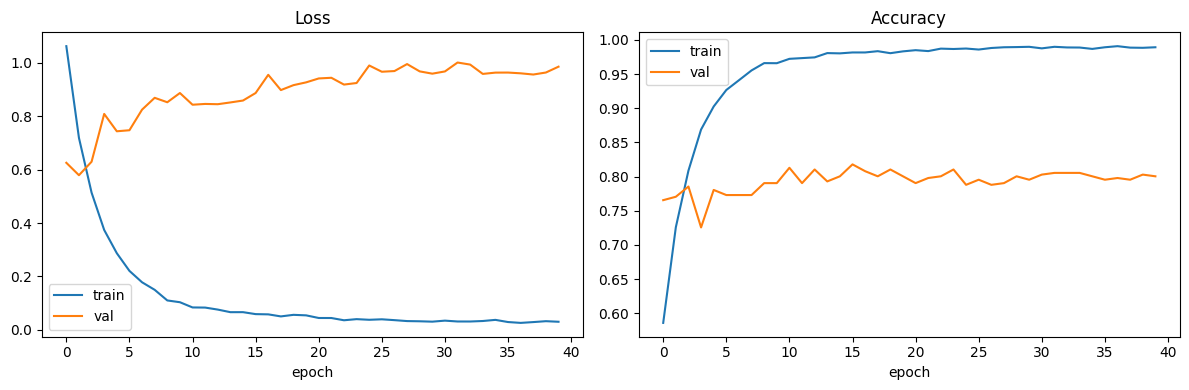

In [ ]:
# @title 10d. Plot training curves
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history["train_loss"], label="train")
ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss")
ax[0].set_xlabel("epoch")
ax[0].legend()
ax[1].plot(history["train_acc"], label="train")
ax[1].plot(history["val_acc"], label="val")
ax[1].set_title("Accuracy")
ax[1].set_xlabel("epoch")
ax[1].legend()
plt.tight_layout()
plt.show()

## 11. Evaluasi deterministik pada test set (dropout off, single pass)

In [ ]:
# @title 11a. Load best checkpoint & deterministic evaluation
# Pastikan file model ada sebelum load
if not os.path.exists(cfg.CKPT_PATH):
    print(
        f"Error: Checkpoint tidak ditemukan di {cfg.CKPT_PATH}. Pastikan training sudah selesai."
    )
else:
    model.load_state_dict(torch.load(cfg.CKPT_PATH, map_location=device))
    model.eval()

    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs_uint8, labels in test_loader:
            imgs = gpu_preprocess(imgs_uint8, train_mode=False)
            logits = model(imgs)
            probs = F.softmax(logits, dim=1)
            all_preds.append(probs.argmax(dim=1).cpu())
            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_probs = torch.cat(all_probs).numpy()

    acc = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro"
    )
    print(
        f"Deterministic test accuracy: {acc:.4f} | precision {prec:.4f} | recall {rec:.4f} | F1 {f1:.4f}"
    )
    print(
        classification_report(
            all_labels, all_preds, target_names=[f"Grade {i}" for i in range(5)]
        )
    )

Deterministic test accuracy: 0.7985 | precision 0.6676 | recall 0.6555 | F1 0.6564
              precision    recall  f1-score   support

     Grade 0       0.96      0.97      0.97       185
     Grade 1       0.59      0.40      0.48        40
     Grade 2       0.74      0.76      0.75       106
     Grade 3       0.42      0.38      0.40        26
     Grade 4       0.63      0.76      0.69        45

    accuracy                           0.80       402
   macro avg       0.67      0.66      0.66       402
weighted avg       0.79      0.80      0.79       402



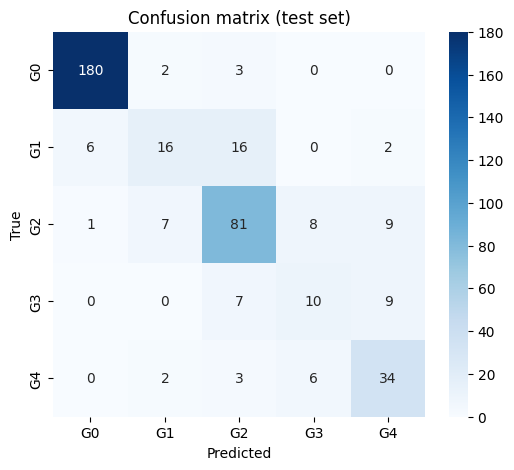

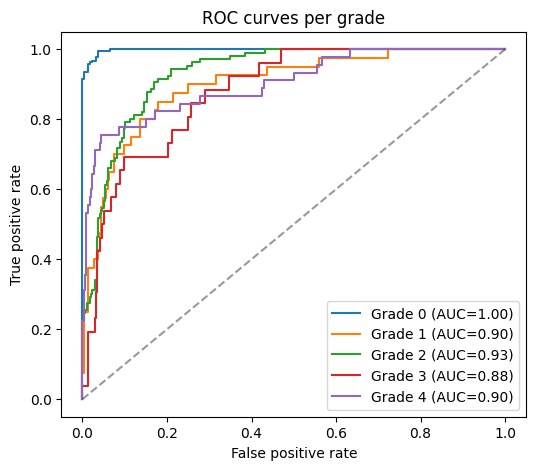

In [ ]:
# @title 11b. Confusion matrix & ROC-AUC per class
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[f"G{i}" for i in range(5)],
    yticklabels=[f"G{i}" for i in range(5)],
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix (test set)")
plt.show()

y_bin = label_binarize(all_labels, classes=list(range(5)))
plt.figure(figsize=(6, 5))
for c in range(5):
    fpr, tpr, _ = roc_curve(y_bin[:, c], all_probs[:, c])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Grade {c} (AUC={roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves per grade")
plt.legend()
plt.show()

## 12. Uncertainty quantification via MC Dropout

`MC_T` forward pass stokastik per citra test, menghasilkan mean prediction (epistemic-aware), predictive entropy, dan variance.

In [ ]:
# @title 12a. Run MC Dropout inference over test set
mc_preds, mc_entropy, mc_variance, mc_labels = [], [], [], []
with torch.no_grad():
    for imgs_uint8, labels in test_loader:
        imgs = gpu_preprocess(imgs_uint8, train_mode=False)
        mean_probs, entropy, variance = mc_dropout_predict(model, imgs, T=cfg.MC_T)
        mc_preds.append(mean_probs.argmax(dim=1).cpu())
        mc_entropy.append(entropy.cpu())
        mc_variance.append(variance.cpu())
        mc_labels.append(labels)

mc_preds = torch.cat(mc_preds).numpy()
mc_entropy = torch.cat(mc_entropy).numpy()
mc_variance = torch.cat(mc_variance).numpy()
mc_labels = torch.cat(mc_labels).numpy()

mc_acc = accuracy_score(mc_labels, mc_preds)
print(f"MC-Dropout-averaged test accuracy (T={cfg.MC_T}): {mc_acc:.4f}")
print(f"Deterministic (single-pass) test accuracy:          {acc:.4f}")

MC-Dropout-averaged test accuracy (T=50): 0.7960
Deterministic (single-pass) test accuracy:          0.7985


In [ ]:
# @title 12b. Predictive entropy: correct vs incorrect predictions
correct_mask = mc_preds == mc_labels
plt.figure(figsize=(7, 4))
sns.kdeplot(mc_entropy[correct_mask], label="correct predictions", fill=True)
sns.kdeplot(mc_entropy[~correct_mask], label="incorrect predictions", fill=True)
plt.xlabel("Predictive entropy")
plt.ylabel("density")
plt.title("Predictive entropy: correct vs incorrect (MC Dropout)")
plt.legend()
plt.show()

print(
    f"Mean entropy | correct: {mc_entropy[correct_mask].mean():.4f} "
    f"| incorrect: {mc_entropy[~correct_mask].mean():.4f}"
)

In [ ]:
# @title 12c. Selective prediction / data-retention curve
order = np.argsort(mc_entropy)  # most confident (lowest entropy) first
sorted_correct = correct_mask[order]

retention_levels = np.linspace(0.1, 1.0, 10)
accs_at_retention = []
for r in retention_levels:
    n = int(len(sorted_correct) * r)
    n = max(n, 1)
    accs_at_retention.append(sorted_correct[:n].mean())

plt.figure(figsize=(6, 4))
plt.plot(retention_levels, accs_at_retention, marker="o")
plt.xlabel("Fraction of data retained (most confident first)")
plt.ylabel("Accuracy on retained subset")
plt.title("Selective prediction curve (MC Dropout uncertainty)")
plt.grid(alpha=0.3)
plt.show()

## 13. Contoh visual: prediksi + uncertainty

Menampilkan beberapa citra test dengan grade prediksi, grade sebenarnya, dan entropy (uncertainty) - berguna untuk memeriksa kasus yang di-flag sebagai "tidak yakin" oleh model.

In [ ]:
# @title 13a. Visualize predictions with uncertainty
sample_idx = np.random.choice(len(test_df), size=6, replace=False)
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, idx in zip(axes.flatten(), sample_idx):
    row = test_df.iloc[idx]
    img = cv2.imread(
        row["filepath"]
    )  # sudah preprocessed & 224x224 dari cache (lihat 6b)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_t = torch.from_numpy(img.transpose(2, 0, 1)).unsqueeze(0)
    tensor = gpu_preprocess(img_t, train_mode=False)
    mean_probs, entropy, variance = mc_dropout_predict(model, tensor, T=cfg.MC_T)
    pred = mean_probs.argmax(dim=1).item()
    ax.imshow(img)
    ax.set_title(f"true={row['label']} pred={pred}\nentropy={entropy.item():.3f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 14. Simpan model & catatan lanjutan

**Poin penting yang perlu diingat saat mengembangkan lebih lanjut:**

- `enable_mc_dropout()` di section 8b adalah bagian paling kritis: BatchNorm **harus** tetap di eval mode (pakai running stats), sementara hanya `nn.Dropout` yang diaktifkan kembali ke train mode. Kalau BatchNorm ikut ke train mode, uncertainty yang terukur akan tercampur noise dari komposisi batch, bukan murni dari ketidaktahuan model.
- `MC_T=50` adalah titik awal yang wajar. Naikkan ke 100 kalau perlu estimasi variance yang lebih halus (linear terhadap biaya komputasi saat inference).
- Citra APTOS dari kagglehub sudah diresize ke 224x224 oleh pembuat dataset (bukan citra resolusi asli) — pipeline preprocessing di section 5 tetap dijalankan di atasnya (crop, radius-normalize, CLAHE), sedikit redundan tapi tidak merusak kualitas secara signifikan.
- Cek dulu jumlah file per kelas di folder lokal Drive kamu (cell 4c mencetaknya) — kalau salah satu kelas sangat sedikit di sumber lokal, `TARGET_PER_CLASS=1500` mungkin perlu diturunkan supaya oversampling-nya tidak terlalu ekstrem.
- Untuk membandingkan head Bayesian ini dengan pendekatan ordinal (CORAL) yang sempat direncanakan sebelumnya, cukup ganti `criterion` di section 9a dan ubah output head jadi K-1 unit biner alih-alih softmax 5-kelas — arsitektur backbone & mekanisme MC Dropout tidak perlu berubah.

In [ ]:
# @title 14a. Save final artifacts
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": cfg.__dict__,
        "history": history,
        "test_accuracy_deterministic": float(acc),
        "test_accuracy_mc_dropout": float(mc_acc),
    },
    cfg.CKPT_PATH,
)
print("Saved to", cfg.CKPT_PATH)

Saved to /content/bayesian_densenet121_mcdropout.pt
